Nama  : Muhammad Abiyyu Arldana Sugianto  
Batch : 059  

notebook ini berisi analisis terkait terkait konsumsi daya listrik, guna mengoptimalkan penggunaan daya listrik pada sebuah pabrik untuk 30 hari kedepan. 

### Import Libraries

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Data Loading

In [17]:
df = pd.read_csv('power_consumption.csv')
print("5 Data Awal: ")
display(df.head(5))

print('5 Data Akhir: ')
display(df.tail(5))

5 Data Awal: 


,Date,Power_Usage
0,2022-01-01,2379
1,2022-01-02,2480
2,2022-01-03,2350
3,2022-01-04,1841
4,2022-01-05,2462


5 Data Akhir: 


,Date,Power_Usage
543,2023-06-28,2621
544,2023-06-29,2553
545,2023-06-30,2326
546,2023-07-01,2461
547,2023-07-02,2395


In [18]:
print('Shape:', df.shape)
df.info()

Shape: (548, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         548 non-null    object
 1   Power_Usage  548 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 8.7+ KB


In [19]:
df.describe()

,Power_Usage
count,548.000000
mean,2480.768248
std,338.957633
min,1500.000000
25%,2240.750000
50%,2519.000000
75%,2759.750000
max,3064.000000


In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').asfreq('D')

### EDA

In [21]:
# split train - test

TEST_RATIO = 0.2
n_test = int(len(df) * TEST_RATIO)

train = df['Power_Usage'].iloc[:-n_test]
test = df['Power_Usage'].iloc[-n_test:]

print(f'Train: {len(train)} day ({train.index.min().date()} untill {train.index.max().date()})')
print(f'Test: {len(train)} day ({test.index.min().date()} untill {test.index.max().date()})')

Train: 439 day (2022-01-01 untill 2023-03-15)
Test: 439 day (2023-03-16 untill 2023-07-02)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14956\1842289936.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([train[train.index.day_name() == d].values for d in order],
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14956\1842289936.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train[train.index.month == m].values for m in months], labels=months)


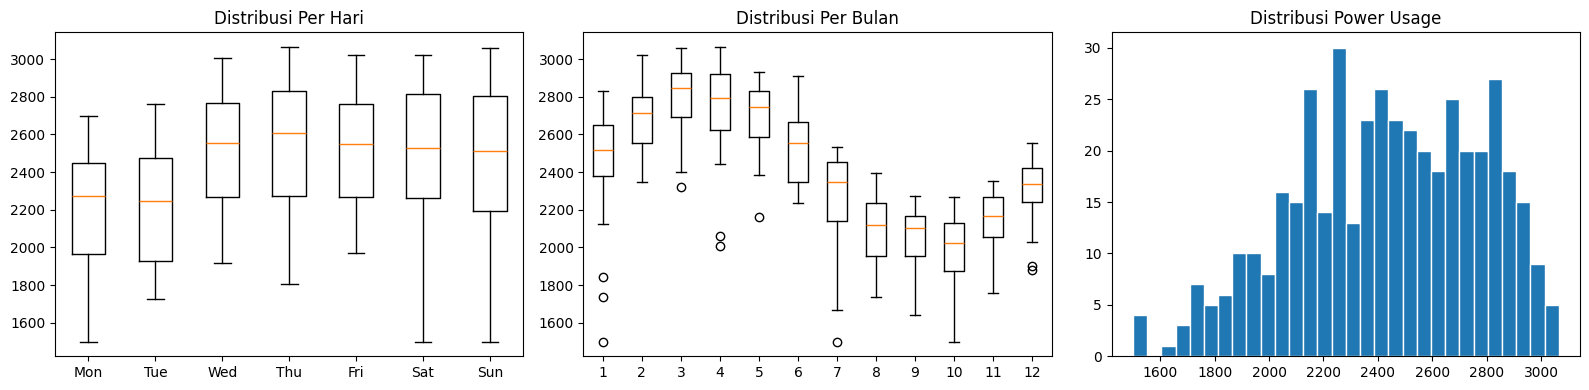

In [22]:
# pola periode per hari, bulan distribusi
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, axes = plt.subplots(1,3, figsize=(16, 4))
axes[0].boxplot([train[train.index.day_name() == d].values for d in order], 
                labels=[d[:3] for d in order])
axes[0].set_title('Distribusi Per Hari')
months = sorted(train.index.month.unique())

axes[1].boxplot([train[train.index.month == m].values for m in months], labels=months)
axes[1].set_title('Distribusi Per Bulan')

axes[2].hist(train, bins=30, edgecolor='white')
axes[2].set_title('Distribusi Power Usage')

plt.tight_layout()
plt.show()

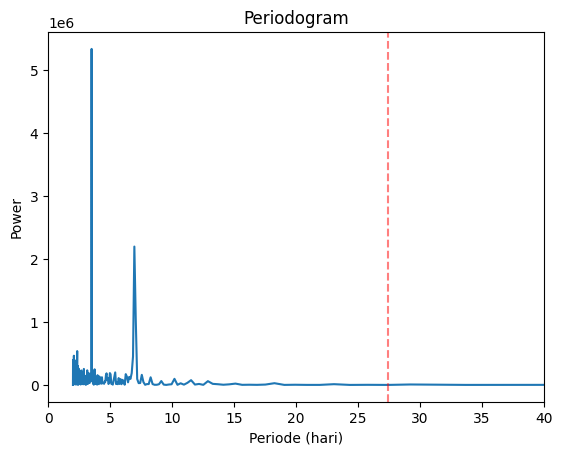

Periode dominan (hari): [146.   109.5   27.38  73.    54.75]


In [23]:
# periode seasonal
detrended = train.diff().dropna()
freqs, power = periodogram(detrended.values, detrend='linear')
mask = freqs > 0
periods = 1 / freqs[mask]
top = np.argsort(power[mask])[::1][:5]

fig, ax = plt.subplots()
ax.plot(periods, power[mask]); ax.set_xlim(0, 40)
ax.set_xlabel('Periode (hari)'); ax.set_ylabel('Power'); ax.set_title('Periodogram')
for i in top[:3]:
    ax.axvline(periods[i], color='red', ls='--', alpha=0.5)
plt.show()

print('Periode dominan (hari):', np.round(periods[top],2))
S = 7

Korelasi rolling mean vs std:  -0.137
Std residual additive       : 128.33
Std residual multiplicative : 129.78


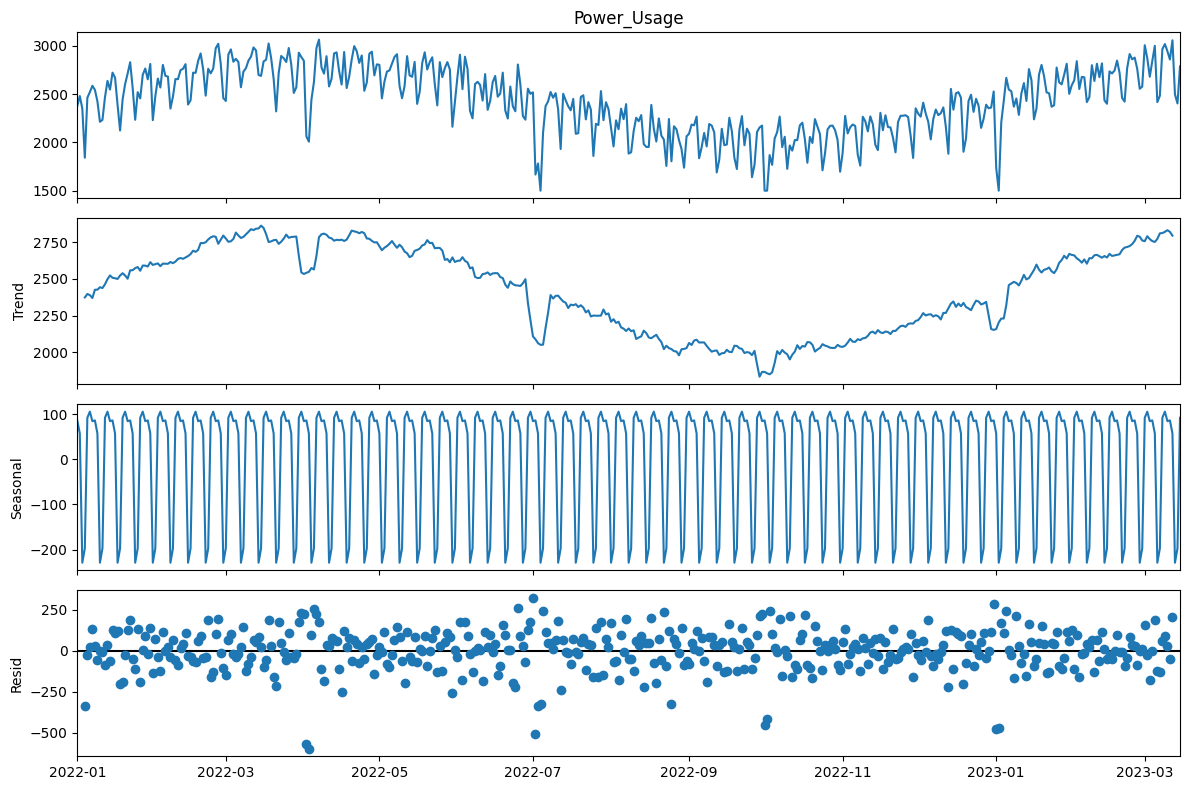

Date
Saturday      86.3
Sunday        57.3
Monday      -229.0
Tuesday     -197.2
Wednesday     92.2
Thursday     105.7
Friday        84.7
Name: seasonal, dtype: float64


In [24]:
# decomposition
roll_mean, roll_std = train.rolling(S).mean(), train.rolling(S).std()
print("Korelasi rolling mean vs std: ", round(roll_mean.corr(roll_std), 3))

# bandingkan residual
dec_add = seasonal_decompose(train, model='additivie', period=S)
dec_mul = seasonal_decompose(train, model='multiplicative', period=S)
res_add = dec_add.resid.dropna()
res_mul = (dec_mul.resid.dropna() - 1) * dec_mul.trend.dropna()

print('Std residual additive       :', round(res_add.std(),2))
print('Std residual multiplicative :', round(res_mul.std(),2))

fig = dec_add.plot(); fig.set_size_inches(12, 8); plt.tight_layout(); plt.show()

# pola seasonal 1 minggu
pola = dec_add.seasonal.iloc[:S].copy()
pola.index = pola.index.day_name()
print(pola.round(1))

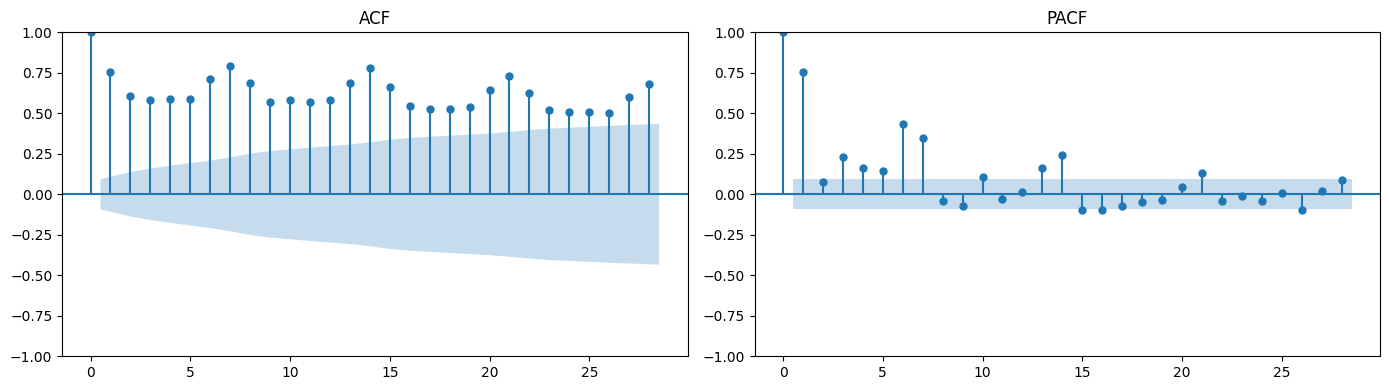

In [26]:
# acf/pacf
LAGS = 4 * S

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train, lags=LAGS, ax=axes[0], title='ACF')
plot_pacf(train, lags=LAGS, ax=axes[1], title='PACF', method='ywm')
plt.tight_layout(); plt.show()

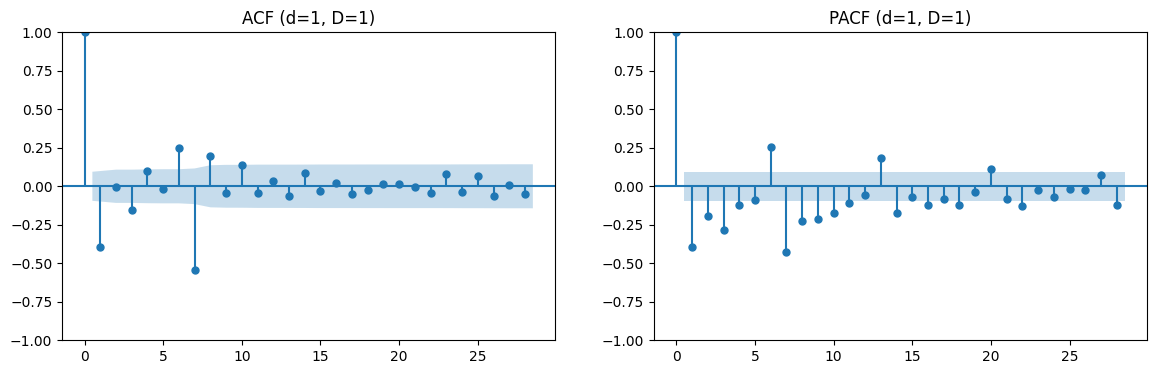

In [31]:
stat = train.diff().diff(S).dropna()
fig, ax = plt.subplots(1,2,figsize=(14,4))
plot_acf(stat, lags=28, ax=ax[0], title='ACF (d=1, D=1)')
plot_pacf(stat, lags=28, ax=ax[1], title='PACF (d=1, D=1)', method='ywm')
plt.show()

In [30]:
# uji stasioner
def uji_adf(series, nama):
    hasil = adfuller(series.dropna(), autolag="AIC")
    print(f'{nama:22s} ADF stat = {hasil[0]:.3} | p-value = {hasil[1]:.4f}')
uji_adf(train, 'Data asli')
uji_adf(train.diff(), 'Diff 1 (d=1)')
uji_adf(train.diff(S), 'Seasonal diff (D=1)')
uji_adf(train.diff().diff(S), 'd=1 dan D=1')

Data asli              ADF stat = -0.654 | p-value = 0.8584
Diff 1 (d=1)           ADF stat = -7.7 | p-value = 0.0000
Seasonal diff (D=1)    ADF stat = -5.84 | p-value = 0.0000
d=1 dan D=1            ADF stat = -9.52 | p-value = 0.0000


### Model

In [34]:
# model definition
arima = SARIMAX(train, order=(0, 1, 1),
                enforce_stationarity=False, 
                enforce_invertibility=False).fit(disp=False)

# dengan kompenen seasonal (S=7)
sarima =  SARIMAX (train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print('ARIMA AIC:', round(arima.aic, 1))
print('SARIMA AIC:', round(sarima.aic, 1))
print(sarima.summary())

ARIMA AIC: 5907.8
SARIMA AIC: 5474.8
                                     SARIMAX Results                                     
Dep. Variable:                       Power_Usage   No. Observations:                  439
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -2734.383
Date:                           Mon, 21 Sep 2026   AIC                           5474.766
Time:                                   11:36:53   BIC                           5486.901
Sample:                               01-01-2022   HQIC                          5479.561
                                    - 03-15-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7937      0.018    -43.221      0.000      -0.830      -0.758
ma.S.L

In [39]:
# model eval (MAE & MAPE)

def eval(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return round(mae, 2), round(mape, 2)

pred_arima = arima.forecast(steps=len(test))
pred_sarima = sarima.forecast(steps=len(test))

mae_arima, mape_arima = eval(test, pred_arima)
mae_sarima, mape_sarima = eval(test, pred_sarima)

hasil = pd.DataFrame({
    "MAE" : [mae_arima, mae_sarima],
    "MAPE (%)" : [mape_arima, mape_sarima],
}, index=['Arima(0,1,1)', 'Sarima(0,1,1)(0,1,1,7)'])
hasil

,MAE,MAPE (%)
"Arima(0,1,1)",174.00,6.91
"Sarima(0,1,1)(0,1,1,7)",175.71,6.95


SyntaxError: keyword argument repeated: label (1313134542.py, line 11)

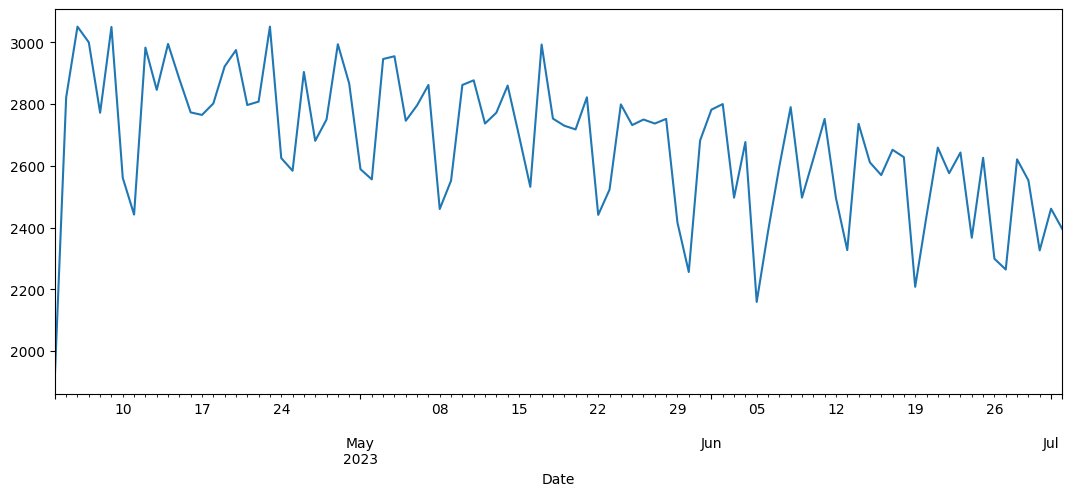

In [41]:
# inference
final = SARIMAX(df["Power_Usage"], order=(0, 1, 1), seasonal_order=(0, 1, 1, 7),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

fc = final.get_forecast(steps=30)
forecast = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

plt.figure(figsize=(13, 5))
df['Power_Usage'].iloc[-90:].plot(label='Data Historis')
forecast.plot(label='Forecast 30 hari', color='red', alpha=0.15, label='Interval 95%')
plt.title("Forecast konsumsi listrik 30 hari kedepan"); plt.ylabel('Mwh'); plt.legend(); plt.show()

forecast.round(1)